In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("matches.csv")

print(df.info()) 

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [10]:
df = df.dropna(subset=['winner'])
print(df["winner"].value_counts())

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


In [12]:
print(df.duplicated().sum())
print(df.isnull().sum())

0
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64


In [13]:
df["city"] = df["city"].fillna("Unknown")
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   str           
 2   city             1090 non-null   str           
 3   date             1090 non-null   datetime64[us]
 4   match_type       1090 non-null   str           
 5   player_of_match  1090 non-null   str           
 6   venue            1090 non-null   str           
 7   team1            1090 non-null   str           
 8   team2            1090 non-null   str           
 9   toss_winner      1090 non-null   str           
 10  toss_decision    1090 non-null   str           
 11  winner           1090 non-null   str           
 12  result           1090 non-null   str           
 13  result_margin    1076 non-null   float64       
 14  target_runs      1090 non-null   float64       
 15  tar

In [18]:
df["city"] = df["city"].fillna("Unknown")
df["toss_decision"] = df["toss_decision"].str.lower()
df["team1"] = df["team1"].replace({
    "Delhi Daredevils":"Delhi Capitals",
    "Kings XI Punjab":"Punjab Kings",
    "Royal Challengers Bangalore":"Royal Challengers Bengaluru",
    "Gujarat Lions":"Gujarat Titans",
    "Rising Pune Supergiants":"Rising Pune Supergiant"
    
})

df["team2"] = df["team2"].replace({
    "Delhi Daredevils":"Delhi Capitals",
    "Kings XI Punjab":"Punjab Kings",
    "Royal Challengers Bangalore":"Royal Challengers Bengaluru",
    "Gujarat Lions":"Gujarat Titans",
    "Rising Pune Supergiants":"Rising Pune Supergiant"
})

df["toss_winner"] = df["toss_winner"].replace({
    "Delhi Daredevils":"Delhi Capitals",
    "Kings XI Punjab":"Punjab Kings",
    "Royal Challengers Bangalore":"Royal Challengers Bengaluru",
    "Gujarat Lions":"Gujarat Titans",
    "Rising Pune Supergiants":"Rising Pune Supergiant"
})


df["winner"] = df["winner"].replace({
    "Delhi Daredevils":"Delhi Capitals",
    "Kings XI Punjab":"Punjab Kings",
    "Royal Challengers Bangalore":"Royal Challengers Bengaluru",
    "Gujarat Lions":"Gujarat Titans",
    "Rising Pune Supergiants":"Rising Pune Supergiant"
})
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [19]:
print(df["winner"].value_counts())
df.info()
df.head()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Gujarat Titans                  41
Deccan Chargers                 29
Lucknow Super Giants            24
Rising Pune Supergiant          15
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   str           
 2   city             1090 non-null   str           
 3   date             1090 non-null   datetime64[us]
 4   match_type       1090 non-null   str           
 5   player_of_

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


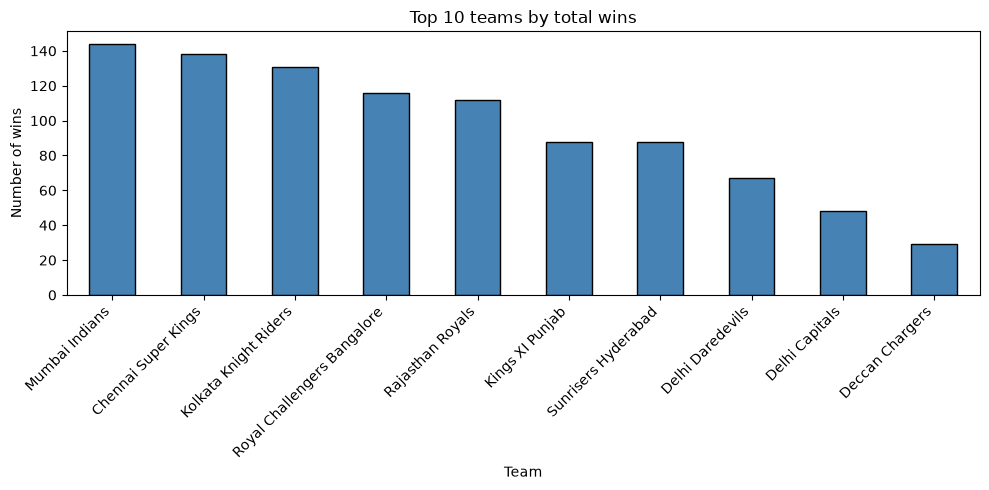

In [24]:
top_teams = df['winner'].value_counts().head(10)
print(top_teams)

plt.figure(figsize=(10, 5))
top_teams.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 teams by total wins')
plt.xlabel('Team')
plt.ylabel('Number of wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_teams.png')
plt.show()

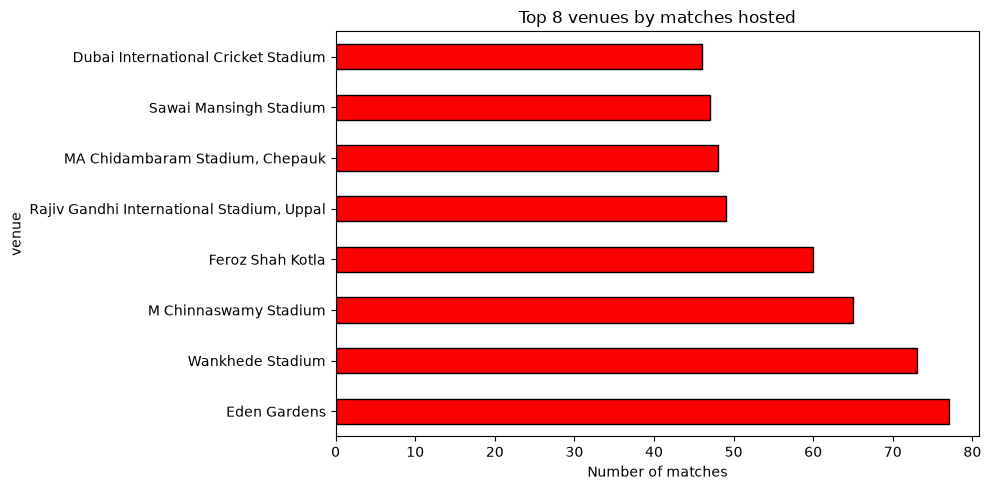

In [25]:
top_venues = df['venue'].value_counts().head(8)

plt.figure(figsize=(10, 5))
top_venues.plot(kind='barh', color='red', edgecolor='black')
plt.title('Top 8 venues by matches hosted')
plt.xlabel('Number of matches')
plt.tight_layout()
plt.savefig('top_venues.png')
plt.show()

Toss winner also won the match: 50.6% of the time
toss_decision
field    704
bat      391
Name: count, dtype: int64


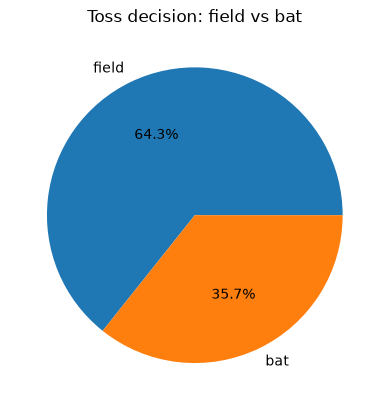

In [28]:

toss_match_winner = df[df['toss_winner'] == df['winner']]
toss_advantage = len(toss_match_winner) / len(df) * 100

print(f"Toss winner also won the match: {toss_advantage:.1f}% of the time")

toss_decision = df['toss_decision'].value_counts()
print(toss_decision)

toss_decision.plot(kind='pie', autopct='%1.1f%%')
plt.title('Toss decision: field vs bat')
plt.savefig('toss_decision.png')
plt.show()

C:\Users\Arushi\AppData\Local\Temp\ipykernel_18580\1663418013.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = season_top3[season_wins['winner'] == team]
C:\Users\Arushi\AppData\Local\Temp\ipykernel_18580\1663418013.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = season_top3[season_wins['winner'] == team]
C:\Users\Arushi\AppData\Local\Temp\ipykernel_18580\1663418013.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = season_top3[season_wins['winner'] == team]


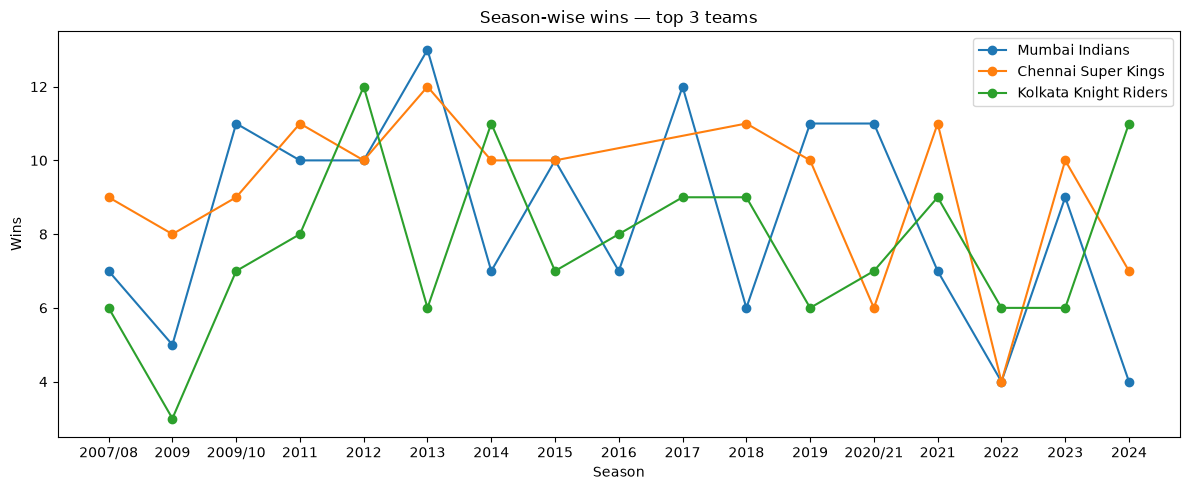

In [31]:
season_wins = df.groupby(['season', 'winner']).size().reset_index(name='wins')
top3 = df['winner'].value_counts().head(3).index.tolist()

season_top3 = season_wins[season_wins['winner'].isin(top3)]

plt.figure(figsize=(12, 5))
for team in top3:
    data = season_top3[season_wins['winner'] == team]
    plt.plot(data['season'], data['wins'], marker='o', label=team)

plt.title('Season-wise wins — top 3 teams')
plt.xlabel('Season')
plt.ylabel('Wins')
plt.legend()
plt.tight_layout()
plt.savefig('season_wins.png')
plt.show()